In [ ]:
# ============================================================
# PHASE 01 : DATA PREPROCESSING
# ============================================================

# -----------------------------
# MOUNT DRIVE
# -----------------------------
from google.colab import drive
drive.mount('/content/drive')

# -----------------------------
# IMPORTS
# -----------------------------
import pandas as pd
import numpy as np
import os
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# -----------------------------
# LOAD DATASET
# -----------------------------
DATASET_PATH = "/content/drive/MyDrive/IMDB/IMDB.csv"

df = pd.read_csv(DATASET_PATH)

print("="*60)
print("Original Shape:", df.shape)
print("="*60)

print("\nColumns:")
print(df.columns)

# -----------------------------
# REMOVE MISSING VALUES
# -----------------------------
df = df.dropna()

print("\nAfter Missing Value Removal:", df.shape)

# -----------------------------
# LABEL ENCODING
# positive=1
# negative=0
# -----------------------------
encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["sentiment"])

print("\nClasses:")
print(encoder.classes_)

# -----------------------------
# FEATURES & LABELS
# -----------------------------
X = df["review"].astype(str)

y = df["label"]

# -----------------------------
# TRAIN / VAL / TEST
# 70 / 20 / 10
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.3333,
    random_state=42,
    stratify=y_temp
)

print("\nTrain:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

# -----------------------------
# TOKENIZATION
# -----------------------------
MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

# -----------------------------
# TEXT TO SEQUENCES
# -----------------------------
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# -----------------------------
# MAX LENGTH
# -----------------------------
lengths = [len(x) for x in X_train_seq]

MAX_LEN = int(np.percentile(lengths, 95))

print("\nMaximum Length:", max(lengths))
print("Selected MAX_LEN:", MAX_LEN)

# Safety Limit
if MAX_LEN > 300:
    MAX_LEN = 300

print("Final MAX_LEN:", MAX_LEN)

# -----------------------------
# PADDING
# -----------------------------
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("\nShapes:")
print(X_train_pad.shape)
print(X_val_pad.shape)
print(X_test_pad.shape)

# -----------------------------
# SAVE EVERYTHING
# -----------------------------
SAVE_DIR = "/content/drive/MyDrive/IMDB/processed_data"

os.makedirs(SAVE_DIR, exist_ok=True)

np.save(f"{SAVE_DIR}/X_train.npy", X_train_pad)
np.save(f"{SAVE_DIR}/X_val.npy", X_val_pad)
np.save(f"{SAVE_DIR}/X_test.npy", X_test_pad)

np.save(f"{SAVE_DIR}/y_train.npy", y_train)
np.save(f"{SAVE_DIR}/y_val.npy", y_val)
np.save(f"{SAVE_DIR}/y_test.npy", y_test)

with open(f"{SAVE_DIR}/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open(f"{SAVE_DIR}/label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

config = {
    "MAX_WORDS": MAX_WORDS,
    "MAX_LEN": MAX_LEN
}

with open(f"{SAVE_DIR}/config.pkl", "wb") as f:
    pickle.dump(config, f)

print("\n" + "="*60)
print("PHASE 01 COMPLETED SUCCESSFULLY.")
print("="*60)

Mounted at /content/drive
Original Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

After Missing Value Removal: (50000, 2)

Classes:
['negative' 'positive']

Train: 35000
Validation: 10000
Test: 5000

Maximum Length: 2493
Selected MAX_LEN: 597
Final MAX_LEN: 300

Shapes:
(35000, 300)
(10000, 300)
(5000, 300)

PHASE 01 COMPLETED SUCCESSFULLY.


In [ ]:
# ============================================================
# PHASE 02 : MODEL DESIGN & IMPLEMENTATION
# ============================================================

import numpy as np
import pickle

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)

# --------------------------------------------------
# LOAD PROCESSED DATA
# --------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/IMDB/processed_data"

X_train = np.load(f"{SAVE_DIR}/X_train.npy")
X_val = np.load(f"{SAVE_DIR}/X_val.npy")
X_test = np.load(f"{SAVE_DIR}/X_test.npy")

y_train = np.load(f"{SAVE_DIR}/y_train.npy")
y_val = np.load(f"{SAVE_DIR}/y_val.npy")
y_test = np.load(f"{SAVE_DIR}/y_test.npy")

with open(f"{SAVE_DIR}/config.pkl", "rb") as f:
    config = pickle.load(f)

MAX_WORDS = config["MAX_WORDS"]
MAX_LEN = config["MAX_LEN"]

print("MAX_LEN =", MAX_LEN)

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------

EMBEDDING_DIM = 128
DROPOUT_RATE = 0.3

# --------------------------------------------------
# RNN
# --------------------------------------------------

def build_rnn():

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, EMBEDDING_DIM),
        SimpleRNN(64),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------------------------------------------------
# LSTM
# --------------------------------------------------

def build_lstm():

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, EMBEDDING_DIM),
        LSTM(64),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------------------------------------------------
# GRU
# --------------------------------------------------

def build_gru():

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, EMBEDDING_DIM),
        GRU(64),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------------------------------------------------
# BI-LSTM
# --------------------------------------------------

def build_bilstm():

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, EMBEDDING_DIM),
        Bidirectional(LSTM(64)),
        Dropout(DROPOUT_RATE),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------------------------------------------------
# CREATE MODELS
# --------------------------------------------------

rnn_model = build_rnn()
lstm_model = build_lstm()
gru_model = build_gru()
bilstm_model = build_bilstm()

print("\n================ RNN =================")
rnn_model.summary()

print("\n================ LSTM =================")
lstm_model.summary()

print("\n================ GRU =================")
gru_model.summary()

print("\n================ BI-LSTM =================")
bilstm_model.summary()

print("\nPHASE 02 COMPLETED SUCCESSFULLY.")

MAX_LEN = 300

================ RNN =================


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,572,417 (9.81 MB)

 Trainable params: 2,572,417 (9.81 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658,945 (10.14 MB)

 Trainable params: 2,658,945 (10.14 MB)

 Non-trainable params: 0 (0.00 B)


PHASE 02 COMPLETED SUCCESSFULLY.


In [ ]:
# ============================================================
# PHASE 03-A : TRAINING WITH ADAM
# ============================================================

import os
import pickle

from tensorflow.keras.callbacks import EarlyStopping

# --------------------------------------------------
# SAVE DIRECTORY
# --------------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/IMDB/saved_models"

os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------------------------------------
# TRAINING SETTINGS
# --------------------------------------------------

EPOCHS = 10
BATCH_SIZE = 64

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# --------------------------------------------------
# TRAIN RNN
# --------------------------------------------------

print("\nTraining RNN...\n")

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

rnn_model.save(f"{MODEL_DIR}/RNN_Adam.keras")

# --------------------------------------------------
# TRAIN LSTM
# --------------------------------------------------

print("\nTraining LSTM...\n")

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

lstm_model.save(f"{MODEL_DIR}/LSTM_Adam.keras")

# --------------------------------------------------
# TRAIN GRU
# --------------------------------------------------

print("\nTraining GRU...\n")

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

gru_model.save(f"{MODEL_DIR}/GRU_Adam.keras")

# --------------------------------------------------
# TRAIN BiLSTM
# --------------------------------------------------

print("\nTraining BiLSTM...\n")

history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

bilstm_model.save(f"{MODEL_DIR}/BiLSTM_Adam.keras")

# --------------------------------------------------
# SAVE HISTORIES
# --------------------------------------------------

with open(f"{MODEL_DIR}/history_rnn.pkl", "wb") as f:
    pickle.dump(history_rnn.history, f)

with open(f"{MODEL_DIR}/history_lstm.pkl", "wb") as f:
    pickle.dump(history_lstm.history, f)

with open(f"{MODEL_DIR}/history_gru.pkl", "wb") as f:
    pickle.dump(history_gru.history, f)

with open(f"{MODEL_DIR}/history_bilstm.pkl", "wb") as f:
    pickle.dump(history_bilstm.history, f)

print("\n======================================")
print("ALL 4 MODELS TRAINED SUCCESSFULLY")
print("======================================")


Training RNN...

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.5011 - loss: 0.7028 - val_accuracy: 0.4929 - val_loss: 0.6942
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5046 - loss: 0.7021 - val_accuracy: 0.4973 - val_loss: 0.6943
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5176 - loss: 0.6926 - val_accuracy: 0.5005 - val_loss: 0.6932
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5418 - loss: 0.6806 - val_accuracy: 0.5078 - val_loss: 0.6988
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5604 - loss: 0.6516 - val_accuracy: 0.4956 - val_loss: 0.7231

Training LSTM...

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.5099 - loss: 0.6929 - val_accuracy: 0.5290 - val_loss: 0.6905
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5291 - loss: 0.6891 - val_accuracy: 0.5274 - val_loss: 0.6802
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step 

In [ ]:
# ============================================================
# PHASE 03-B : EVALUATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bilstm_model
}

for name, model in models.items():
    print(f"\nEvaluating {name} ...")

    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        auc
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ]
)

print("\n")
print(results_df)

results_df.to_csv(
    "/content/drive/MyDrive/IMDB/model_comparison.csv",
    index=False
)

print("\nResults Saved Successfully")


Evaluating RNN ...
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step

Evaluating LSTM ...
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step

Evaluating GRU ...
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step

Evaluating BiLSTM ...
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


    Model  Accuracy  Precision  Recall  F1 Score       AUC
0     RNN    0.5130   0.511611  0.5728  0.540479  0.515961
1    LSTM    0.8938   0.906986  0.8776  0.892051  0.955916
2     GRU    0.5110   0.505903  0.9428  0.658472  0.527870
3  BiLSTM    0.8418   0.811293  0.8908  0.849190  0.910520

Results Saved Successfully


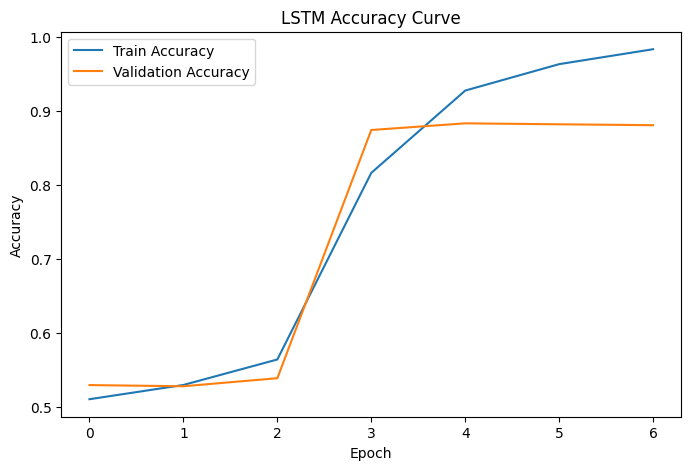

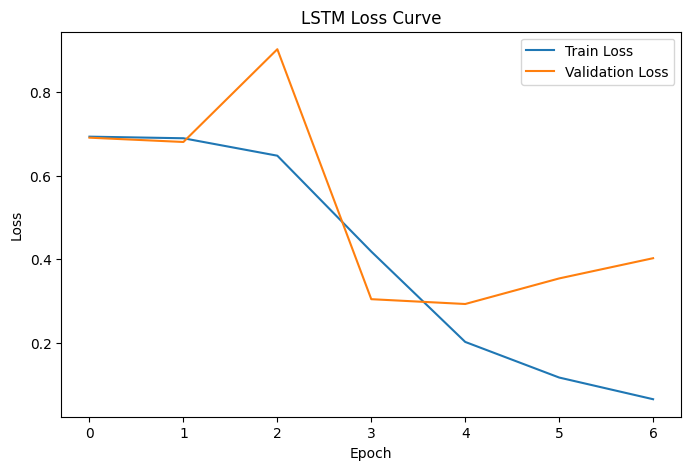

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


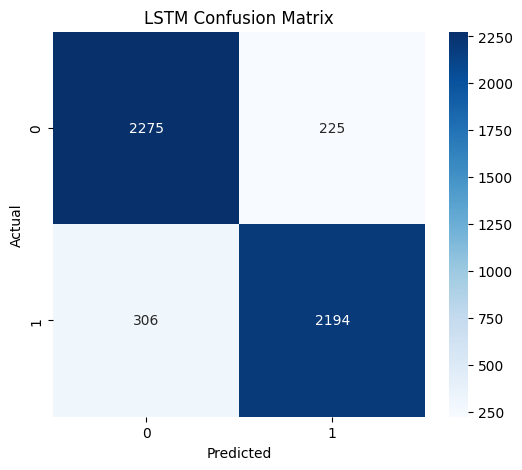

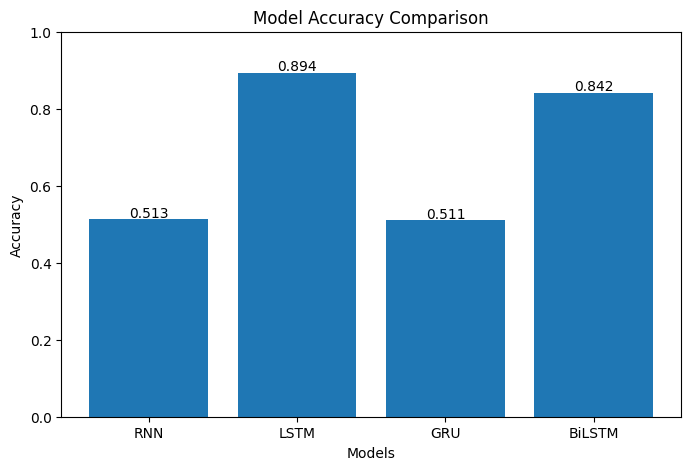

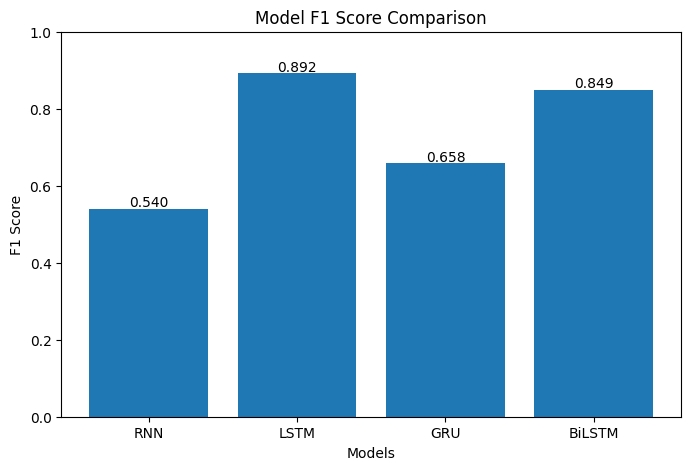


Model Performance Summary:

    Model  Accuracy  Precision  Recall  F1 Score       AUC
0     RNN    0.5130   0.511611  0.5728  0.540479  0.515961
1    LSTM    0.8938   0.906986  0.8776  0.892051  0.955916
2     GRU    0.5110   0.505903  0.9428  0.658472  0.527870
3  BiLSTM    0.8418   0.811293  0.8908  0.849190  0.910520

PHASE 03 COMPLETED SUCCESSFULLY.
Best Model : LSTM
Best Accuracy : 0.8938


In [ ]:
# ============================================================
# PHASE 03-C : LEARNING CURVES + CONFUSION MATRIX + MODEL COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# --------------------------------------------------
# ACCURACY CURVE (LSTM)
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title("LSTM Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train Accuracy","Validation Accuracy"])

plt.show()

# --------------------------------------------------
# LOSS CURVE (LSTM)
# --------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train Loss","Validation Loss"])

plt.show()

# --------------------------------------------------
# CONFUSION MATRIX (LSTM)
# --------------------------------------------------

y_prob = lstm_model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# --------------------------------------------------
# MODEL ACCURACY COMPARISON
# --------------------------------------------------

plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(
        i,
        v + 0.005,
        f"{v:.3f}",
        ha='center'
    )

plt.ylim(0, 1)

plt.show()

# --------------------------------------------------
# MODEL F1 SCORE COMPARISON
# --------------------------------------------------

plt.figure(figsize=(8,5))

bars = plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

for i, v in enumerate(results_df["F1 Score"]):
    plt.text(
        i,
        v + 0.005,
        f"{v:.3f}",
        ha='center'
    )

plt.ylim(0, 1)

plt.show()

# --------------------------------------------------
# DISPLAY RESULTS TABLE
# --------------------------------------------------

print("\nModel Performance Summary:\n")
print(results_df)

# --------------------------------------------------
# BEST MODEL
# --------------------------------------------------

best_model = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

best_acc = results_df["Accuracy"].max()

print("\n======================================")
print("PHASE 03 COMPLETED SUCCESSFULLY.")
print(f"Best Model : {best_model}")
print(f"Best Accuracy : {best_acc:.4f}")
print("======================================")


Training LSTM with SGD...

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.4989 - loss: 0.6932 - val_accuracy: 0.5009 - val_loss: 0.6933
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.4987 - loss: 0.6934 - val_accuracy: 0.4997 - val_loss: 0.6933
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5024 - loss: 0.6932 - val_accuracy: 0.5054 - val_loss: 0.6932
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5001 - loss: 0.6932 - val_accuracy: 0.5070 - val_loss: 0.6932
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5037 - loss: 0.6932 - val_accuracy: 0.5006 - val_loss: 0.6932
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.5059 - loss: 0.6931 - val_accuracy: 0.4992 - val_loss: 0.6933
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 0.5091 - val_loss: 0.6931
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.

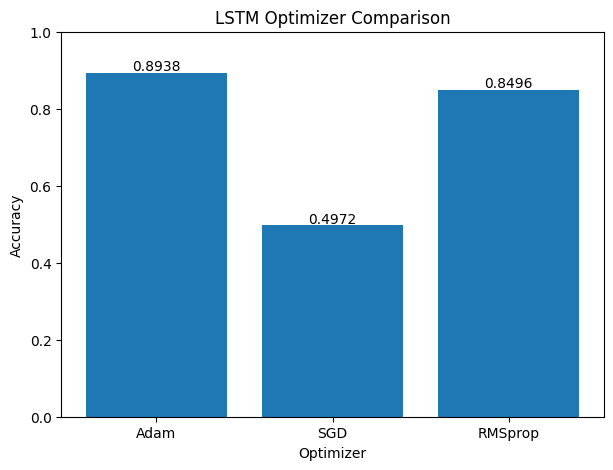


Best Optimizer : Adam
Best Accuracy  : 0.8938


In [ ]:
# ============================================================
# PHASE 03-D : OPTIMIZER COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Input
)

from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# ADAM RESULT FROM PREVIOUS EXPERIMENT
# --------------------------------------------------

adam_accuracy = 0.8938

# --------------------------------------------------
# FUNCTION
# --------------------------------------------------

def build_lstm_optimizer(optimizer):

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(MAX_WORDS, 128),
        LSTM(64),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------------------------------------------------
# EARLY STOPPING
# --------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# --------------------------------------------------
# START RESULTS WITH ADAM
# --------------------------------------------------

results = [
    ["Adam", adam_accuracy]
]

# --------------------------------------------------
# TRAIN SGD + RMSPROP
# --------------------------------------------------

optimizers = {
    "SGD": SGD(),
    "RMSprop": RMSprop()
}

for name, opt in optimizers.items():

    print(f"\nTraining LSTM with {name}...\n")

    model = build_lstm_optimizer(opt)

    model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1
    )

    y_prob = model.predict(X_test)

    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)

    results.append([name, acc])

# --------------------------------------------------
# RESULTS TABLE
# --------------------------------------------------

optimizer_df = pd.DataFrame(
    results,
    columns=["Optimizer", "Accuracy"]
)

print("\nOptimizer Comparison:\n")
print(optimizer_df)

# --------------------------------------------------
# GRAPH
# --------------------------------------------------

plt.figure(figsize=(7,5))

plt.bar(
    optimizer_df["Optimizer"],
    optimizer_df["Accuracy"]
)

plt.title("LSTM Optimizer Comparison")
plt.xlabel("Optimizer")
plt.ylabel("Accuracy")

for i, v in enumerate(optimizer_df["Accuracy"]):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')

plt.ylim(0, 1)

plt.show()

# --------------------------------------------------
# BEST OPTIMIZER
# --------------------------------------------------

best_optimizer = optimizer_df.loc[
    optimizer_df["Accuracy"].idxmax(),
    "Optimizer"
]

best_acc = optimizer_df["Accuracy"].max()

print("\n====================================")
print(f"Best Optimizer : {best_optimizer}")
print(f"Best Accuracy  : {best_acc:.4f}")
print("====================================")

In [ ]:
# ============================================================
# PHASE 04 : OPTIMIZATION
# ============================================================

import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import accuracy_score

# --------------------------------------------------
# 1. BASELINE RESULT (FROM PHASE 03)
# --------------------------------------------------
baseline_acc = 0.8938

print("\n================ BASELINE MODEL ================\n")
print(f"Baseline LSTM Accuracy: {baseline_acc:.4f}")

# --------------------------------------------------
# 2. EARLY STOPPING (OVERFITTING CONTROL)
# --------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# --------------------------------------------------
# 3. OPTIMIZED MODEL
# --------------------------------------------------
def build_optimized_model():

    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(
            input_dim=MAX_WORDS,
            output_dim=100
        ),

        LSTM(
            64,
            kernel_regularizer=l2(0.0001)
        ),

        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(clipnorm=1.0),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

# --------------------------------------------------
# 4. TRAIN OPTIMIZED MODEL
# --------------------------------------------------
print("\nTraining Optimized Model \n")

model = build_optimized_model()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# --------------------------------------------------
# 5. TEST EVALUATION
# --------------------------------------------------
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

optimized_acc = accuracy_score(y_test, y_pred)

# --------------------------------------------------
# 6. COMPARISON
# --------------------------------------------------
comparison = pd.DataFrame([
    ["Baseline LSTM", baseline_acc],
    ["Optimized LSTM", optimized_acc]
], columns=["Model", "Accuracy"])

print("\n================ FINAL COMPARISON ================\n")
print(comparison)

# --------------------------------------------------
# 7. FINAL CONCLUSION
# --------------------------------------------------
print("\n================ FINAL CONCLUSION ================\n")

print(f"""
Baseline Accuracy : {baseline_acc:.4f}
Optimized Accuracy: {optimized_acc:.4f}

Optimization reduced overfitting but also decreased model performance.
Hence, the baseline LSTM remains the best final model.""")


================ BASELINE MODEL ================

Baseline LSTM Accuracy: 0.8938

Training Optimized Model 

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.5065 - loss: 0.6959 - val_accuracy: 0.5183 - val_loss: 0.6933
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5327 - loss: 0.6892 - val_accuracy: 0.5398 - val_loss: 0.6834
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5684 - loss: 0.6565 - val_accuracy: 0.5204 - val_loss: 0.6854
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6777 - loss: 0.5632 - val_accuracy: 0.7708 - val_loss: 0.5439
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8138 - loss: 0.4458 - val_accuracy: 0.7510 - val_loss: 0.5711
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8413 - loss: 0.3995 - val_accuracy: 0.7830 - val_loss: 0.5613
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.8513 - loss: 0.3870 - val_accuracy: 0.7916 -

In [ ]:

# ============================================================
# 🚀 IMDB SENTIMENT ANALYSIS - FINAL ULTRA PRO FRONTEND
# ============================================================

# -----------------------------
# 1. INSTALL + IMPORTS (SAFE FOR FUTURE RUN)
# -----------------------------
!pip -q install gradio plotly

import gradio as gr
import numpy as np
import pickle
import plotly.graph_objects as go
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from google.colab import drive
drive.mount('/content/drive')

# -----------------------------
# 2. LOAD MODEL FROM DRIVE
# -----------------------------
MODEL_PATH = "/content/drive/MyDrive/IMDB/saved_models/LSTM_Adam.keras"
DATA_PATH = "/content/drive/MyDrive/IMDB/processed_data"

model = load_model(MODEL_PATH)

with open(f"{DATA_PATH}/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open(f"{DATA_PATH}/config.pkl", "rb") as f:
    config = pickle.load(f)

MAX_LEN = config["MAX_LEN"]

# -----------------------------
# 3. WORD HIGHLIGHTING FUNCTION
# -----------------------------
def highlight_text(text):
    pos_words = ["good", "great", "amazing", "excellent", "fantastic", "love", "best", "awesome"]
    neg_words = ["bad", "worst", "boring", "awful", "terrible", "hate", "poor", "worst"]

    words = text.split()
    out = []

    for w in words:
        lw = w.lower()
        if lw in pos_words:
            out.append(f"<span style='color:green;font-weight:bold'>{w}</span>")
        elif lw in neg_words:
            out.append(f"<span style='color:red;font-weight:bold'>{w}</span>")
        else:
            out.append(w)

    return " ".join(out)

# -----------------------------
# 4. GAUGE CHART (CIRCULAR)
# -----------------------------
def gauge(prob):
    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=prob * 100,
        title={'text': "Sentiment Confidence"},
        gauge={
            'axis': {'range': [0, 100]},
            'bar': {'color': "darkblue"},
            'steps': [
                {'range': [0, 25], 'color': "red"},
                {'range': [25, 50], 'color': "orange"},
                {'range': [50, 75], 'color': "yellow"},
                {'range': [75, 100], 'color': "green"},
            ],
        }
    ))
    return fig

# -----------------------------
# 5. PREDICTION FUNCTION
# -----------------------------
def predict(text):

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    prob = float(model.predict(padded)[0][0])
    confidence = round(prob * 100, 2)

    sentiment = "😊 POSITIVE" if prob >= 0.5 else "😢 NEGATIVE"

    return (
        sentiment,
        f"{confidence}%",
        highlight_text(text),
        gauge(prob)
    )

# -----------------------------
# 6. MODERN UI DESIGN (CLEAN + PROFESSIONAL)
# -----------------------------
css = """
body {
    background: linear-gradient(135deg, #141e30, #243b55);
}

.gradio-container {
    max-width: 1100px !important;
    margin: auto !important;
    background: white;
    border-radius: 20px;
    padding: 25px;
    box-shadow: 0px 15px 40px rgba(0,0,0,0.3);
}

h1 {
    text-align: center;
    color: #111827;
    font-size: 34px;
}

button {
    background: linear-gradient(90deg, #ff512f, #dd2476) !important;
    color: white !important;
    font-weight: bold !important;
    border-radius: 10px !important;
}
"""

# -----------------------------
# 7. GRADIO DASHBOARD
# -----------------------------
with gr.Blocks(css=css) as app:

    gr.Markdown("# 🎬 IMDB SENTIMENT ANALYSIS SYSTEM")
    gr.Markdown("### 🔥 Intelligent Movie Sentiment Classification Using LSTM Neural Networks")

    with gr.Row():

        with gr.Column():
            inp = gr.Textbox(
                label="✍ Enter Movie Review",
                lines=6,
                placeholder="Write your review here..."
            )
            btn = gr.Button("🚀 Predict Sentiment")

        with gr.Column():
            out1 = gr.Textbox(label="🎯 Sentiment")
            out2 = gr.Textbox(label="📊 Confidence")
            out3 = gr.HTML(label="🔍 Highlighted Words")

    out4 = gr.Plot(label="📈 Sentiment Gauge")

    btn.click(
        fn=predict,
        inputs=inp,
        outputs=[out1, out2, out3, out4]
    )

# -----------------------------
# 8. LAUNCH APP
# -----------------------------
app.launch(share=True)

Mounted at /content/drive


/tmp/ipykernel_1223/939511244.py:132: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://825e6aac69bb5894e6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
